Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Comparison between frequentist confidence intervals and Bayesian credible intervals.\
Topics and relevant videos: [Confidence intervals for proportions](https://www.youtube.com/watch?v=dlGl2dGNZSI), [Bayesian parametric modeling](https://www.youtube.com/watch?v=G63ZmHg83mg)

Author: Carlos Fernandez-Granda

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta

In [2]:
# Prior 1: Uniform / Uninformative
a1, b1 = 1, 1

# Prior 2: Informative 
a2, b2 = 20, 80

# Prior 3: Misinformed 
a3, b3 = 80, 20

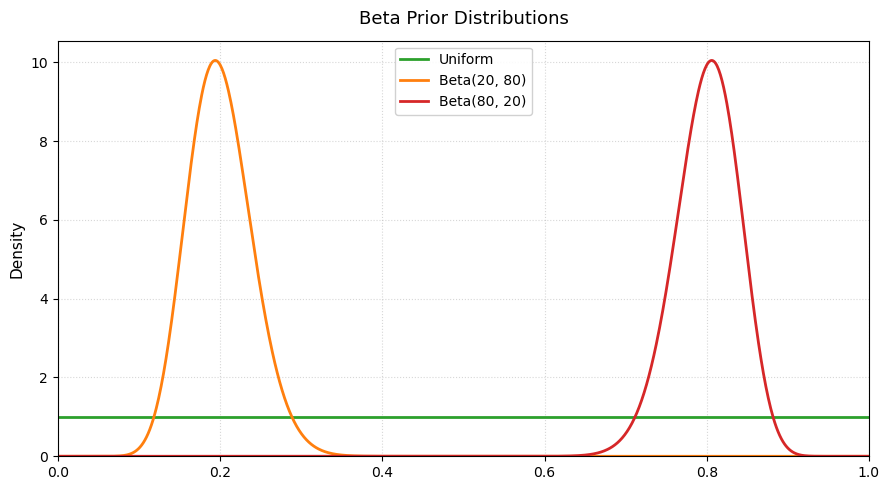

In [3]:
# Grid of values
x = np.linspace(0, 1, 1000)

# Marginal pdfs of priors
y1 = beta.pdf(x, a1, b1)
y2 = beta.pdf(x, a2, b2)
y3 = beta.pdf(x, a3, b3)

# --- Plotting ---
plt.figure(figsize=(9, 5))

plt.plot(x, y1, label=f'Uniform', color='#2ca02c', linewidth=2)
plt.plot(x, y2, label=f'Beta({a2}, {b2})', color='#ff7f0e', linewidth=2)
plt.plot(x, y3, label=f'Beta({a3}, {b3})', color='#d62728', linewidth=2)

plt.title('Beta Prior Distributions', fontsize=13, pad=12)
plt.ylabel('Density', fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, None)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
### Bayesian scenario: Proportion is sampled from a distribution ###

np.random.seed(2026)  # For reproducibility

n = 100             # Sample size per experiment
num_sims = 10_000    # Total simulations 
alpha = 0.05        # Target 95% interval (1 - alpha)

# Data-generating prior
a_gen, b_gen = a2, b2   

# Sample from prior
theta_sampled = np.random.beta(a_gen, b_gen, size=num_sims)

# Sample from likelihood
k_samples = np.random.binomial(n=n, p=theta_sampled)

# Storage for bounds: shape (num_sims, 2)
ci_clt = np.zeros((num_sims, 2))
cred_prior1 = np.zeros((num_sims, 2))
cred_prior2 = np.zeros((num_sims, 2))
cred_prior3 = np.zeros((num_sims, 2))

# Threshold for confidence interval
z_crit = norm.ppf(1 - alpha / 2) # ~1.96 for 95% interval

for i in range(num_sims):
    k = k_samples[i]
    
    # Standard CLT confidence interval
    theta_hat = k / n
    se = np.sqrt(theta_hat * (1 - theta_hat) / n)
    ci_clt[i, 0] = max(0.0, theta_hat - z_crit * se)
    ci_clt[i, 1] = min(1.0, theta_hat + z_crit * se)
    
    # Bayesian credible interval: Uniform prior
    cred_prior1[i] = beta.ppf([alpha/2, 1 - alpha/2], k + a1, n - k + b1)
    
    # Bayesian credible interval: Informative prior
    cred_prior2[i] = beta.ppf([alpha/2, 1 - alpha/2], k + a2, n - k + b2)
    
    # Bayesian credible interval: Misinformed prior
    cred_prior3[i] = beta.ppf([alpha/2, 1 - alpha/2], k + a3, n - k + b3)

# Coverage and average widths
def calc_marginal_coverage(intervals, theta_vec):
    covered = (intervals[:, 0] <= theta_vec) & (theta_vec <= intervals[:, 1])
    return np.mean(covered)

def calc_mean_width(intervals):
    return np.mean(intervals[:, 1] - intervals[:, 0])

cov_clt = calc_marginal_coverage(ci_clt, theta_sampled)
cov_cred1 = calc_marginal_coverage(cred_prior1, theta_sampled)
cov_cred2 = calc_marginal_coverage(cred_prior2, theta_sampled)
cov_cred3 = calc_marginal_coverage(cred_prior3, theta_sampled)

width_clt = calc_mean_width(ci_clt)
width_cred1 = calc_mean_width(cred_prior1)
width_cred2 = calc_mean_width(cred_prior2)
width_cred3 = calc_mean_width(cred_prior3)

print("Performance metrics for probabilistic data generation")
print(f"Standard CLT confidence interval: Coverage = {cov_clt * 100:.2f}%, Mean width = {width_clt:.4f}")
print(f"Bayesian credible interval: Uniform prior: Coverage = {cov_cred1 * 100:.2f}%, Mean width = {width_cred1:.4f}")
print(f"Bayesian credible interval: Informative prior: Coverage = {cov_cred2 * 100:.2f}%, Mean width = {width_cred2:.4f}")
print(f"Bayesian credible interval: Misinformed prior: Coverage = {cov_cred3 * 100:.2f}%, Mean width = {width_cred3:.4f}")

Performance metrics for probabilistic data generation
Standard CLT confidence interval: Coverage = 93.68%, Mean width = 0.1543
Bayesian credible interval: Uniform prior: Coverage = 94.66%, Mean width = 0.1533
Bayesian credible interval: Informative prior: Coverage = 94.52%, Mean width = 0.1099
Bayesian credible interval: Misinformed prior: Coverage = 0.00%, Mean width = 0.1379


NameError: name 'p_true_vec' is not defined

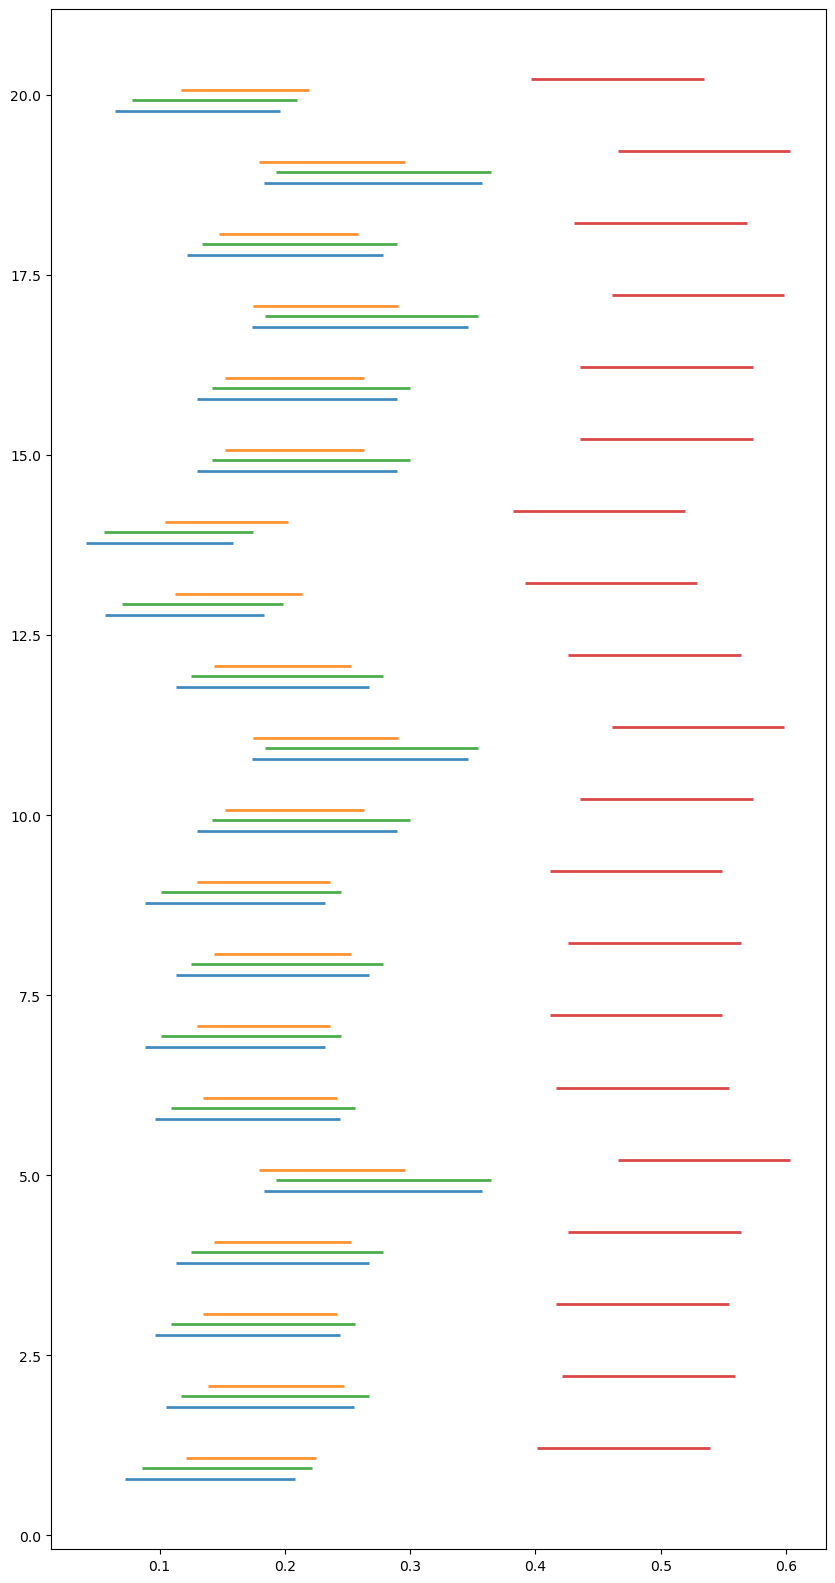

In [5]:
# Number of randomly selected examples to plot
n_plot = 20         
plot_indices = np.random.choice(num_sims, size=n_plot, replace=False)
plot_indices.sort()

plt.figure(figsize=(10, 20))

offsets = [-0.22, -0.07, 0.07, 0.22]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
labels = [
    f'Standard CLT confidence interval',
    f'Bayesian credible interval: Uniform prior',
    f'Bayesian credible interval: Informative prior',
    f'Bayesian credible interval: Misinformed prior'
]

y_positions = np.arange(1, n_plot + 1)

for idx, (intervals, offset, color, label) in enumerate(zip(
    [ci_clt, cred_prior1, cred_prior2, cred_prior3], 
    offsets, 
    colors, 
    labels
)):
    sub_intervals = intervals[plot_indices]
    y_pos = y_positions + offset
    
    plt.hlines(y=y_pos, xmin=sub_intervals[:, 0], xmax=sub_intervals[:, 1], 
               color=color, alpha=0.85, linewidth=2, label=label)

# Plot the corresponding generated true p_i for each shown sample
plt.scatter(p_true_vec[plot_indices], y_positions, color='black', zorder=5, 
            marker='o', s=20, label=r'True proportion (generated probabilistically)')

plt.yticks([])
plt.xlim(0.0, 1)
plt.ylim(0.5, n_plot + 0.5)

plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,  # Wraps the 5 legend items into 2-3 columns so it fits neatly
    fontsize=12
)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [109]:
### Frequentist scenario: Proportion is fixed to theta_true ###

theta_true = 0.2
np.random.seed(2026)  # For reproducibility

# Sample from population
k_samples = np.random.binomial(n=n, p=theta_true, size=num_sims)

# Storage for bounds
ci_clt = np.zeros((num_sims, 2))
cred_prior1 = np.zeros((num_sims, 2))
cred_prior2 = np.zeros((num_sims, 2))
cred_prior3 = np.zeros((num_sims, 2))

for i, k in enumerate(k_samples):
    # Standard CLT confidence interval
    theta_hat = k / n
    se = np.sqrt(theta_hat * (1 - theta_hat) / n)
    ci_clt[i, 0] = max(0.0, theta_hat - z_crit * se)
    ci_clt[i, 1] = min(1.0, theta_hat + z_crit * se)
    
    # Bayesian credible interval: Uniform prior
    cred_prior1[i] = beta.ppf([alpha/2, 1 - alpha/2], k + a1, n - k + b1)
    
    # Bayesian credible interval: Informative prior
    cred_prior2[i] = beta.ppf([alpha/2, 1 - alpha/2], k + a2, n - k + b2)
    
    # Bayesian credible interval: Misinformed prior
    cred_prior3[i] = beta.ppf([alpha/2, 1 - alpha/2], k + a3, n - k + b3)

# Coverage and average widths
def calc_marginal_coverage(intervals, theta_vec):
    covered = (intervals[:, 0] <= theta_vec) & (theta_vec <= intervals[:, 1])
    return np.mean(covered)

def calc_mean_width(intervals):
    widths = intervals[:, 1] - intervals[:, 0]
    return np.mean(widths)

cov_clt = calc_marginal_coverage(ci_clt, theta_true)
cov_cred1 = calc_marginal_coverage(cred_prior1, theta_true)
cov_cred2 = calc_marginal_coverage(cred_prior2, theta_true)
cov_cred3 = calc_marginal_coverage(cred_prior3, theta_true)

width_clt = calc_mean_width(ci_clt)
width_cred1 = calc_mean_width(cred_prior1)
width_cred2 = calc_mean_width(cred_prior2)
width_cred3 = calc_mean_width(cred_prior3)

print("Performance metrics for frequentist data generation")
print(f"Standard CLT confidence interval: Coverage = {cov_clt * 100:.2f}%, Mean width = {width_clt:.4f}")
print(f"Bayesian credible interval: Uniform prior: Coverage = {cov_cred1 * 100:.2f}%, Mean width = {width_cred1:.4f}")
print(f"Bayesian credible interval: Informative prior: Coverage = {cov_cred2 * 100:.2f}%, Mean width = {width_cred2:.4f}")
print(f"Bayesian credible interval: Misinformed prior: Coverage = {cov_cred3 * 100:.2f}%, Mean width = {width_cred3:.4f}")

Performance metrics for frequentist data generation
Standard CLT confidence interval: Coverage = 93.19%, Mean width = 0.1556
Bayesian credible interval: Uniform prior: Coverage = 93.99%, Mean width = 0.1545
Bayesian credible interval: Informative prior: Coverage = 99.40%, Mean width = 0.1102
Bayesian credible interval: Misinformed prior: Coverage = 0.00%, Mean width = 0.1380


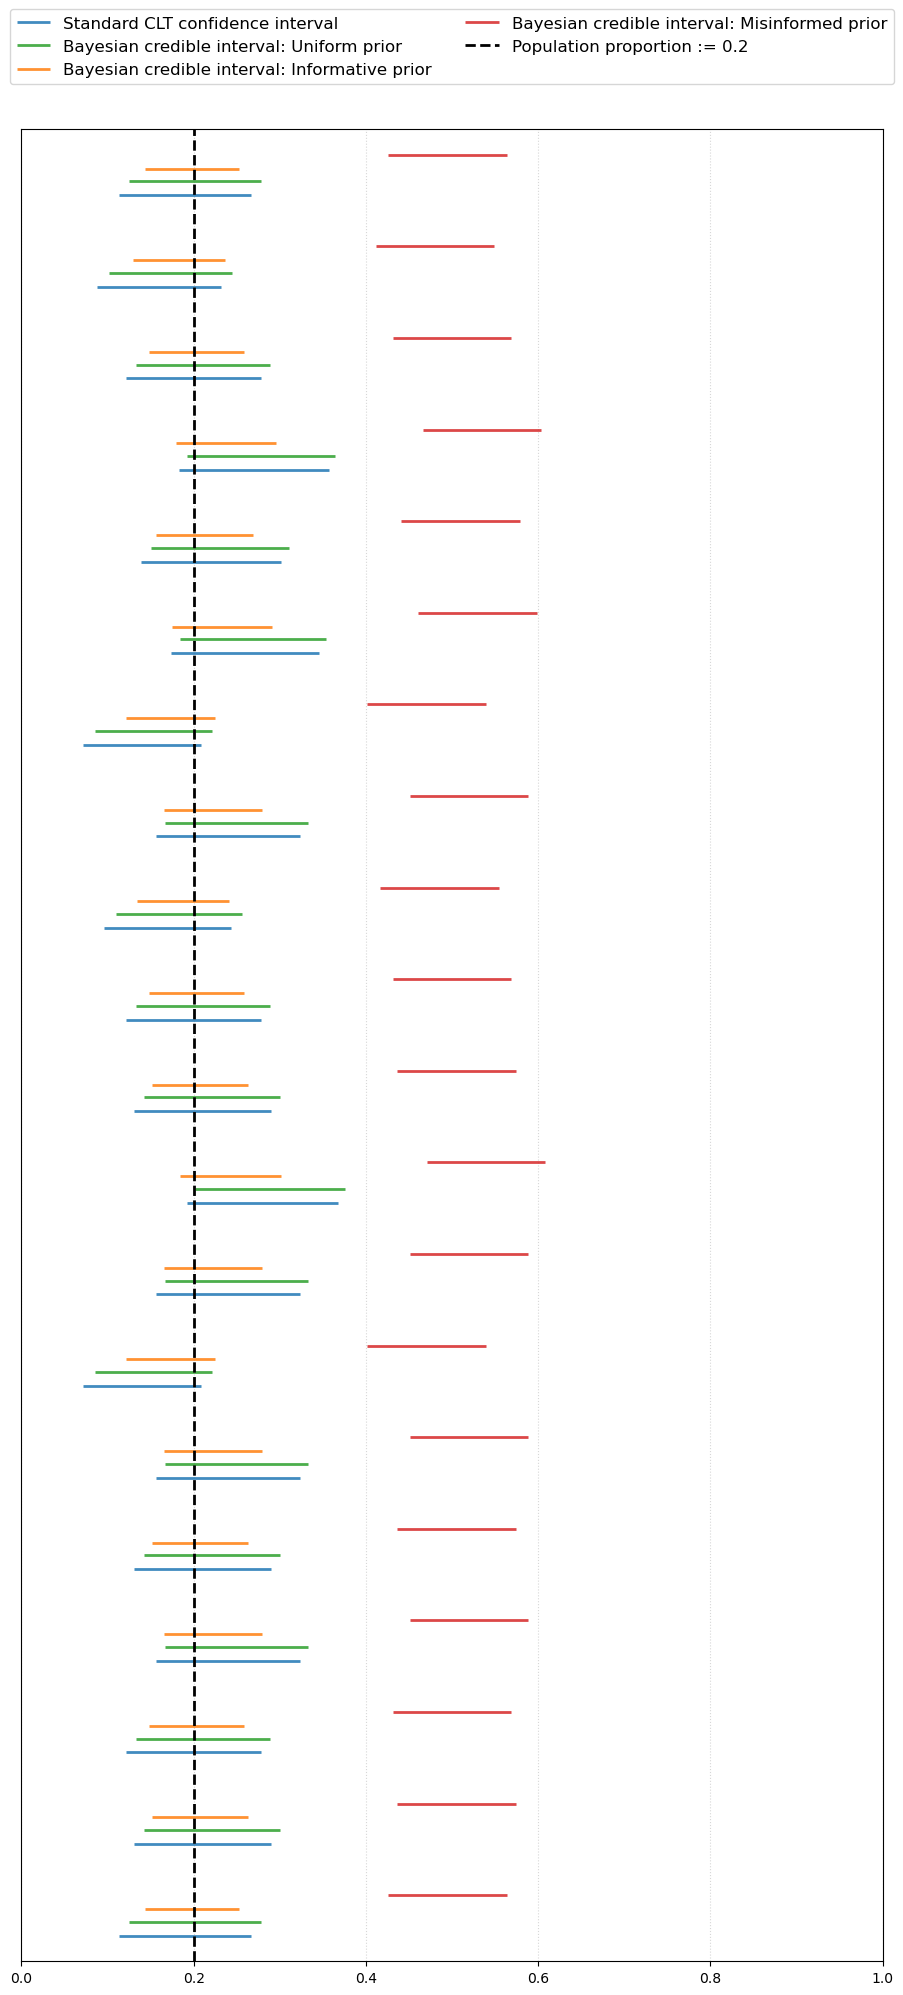

In [110]:
plot_indices = np.random.choice(num_sims, size=n_plot, replace=False)
plot_indices.sort()

plt.figure(figsize=(10, 20))

offsets = [-0.22, -0.07, 0.07, 0.22]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
labels = [
    f'Standard CLT confidence interval',
    f'Bayesian credible interval: Uniform prior',
    f'Bayesian credible interval: Informative prior',
    f'Bayesian credible interval: Misinformed prior'
]

y_positions = np.arange(1, n_plot + 1)

for idx, (intervals, offset, color, label) in enumerate(zip(
    [ci_clt, cred_prior1, cred_prior2, cred_prior3], 
    offsets, 
    colors, 
    labels
)):
    sub_intervals = intervals[plot_indices]
    
    y_pos = y_positions + offset
    x_min = sub_intervals[:, 0]
    x_max = sub_intervals[:, 1]
    
    plt.hlines(y=y_pos, xmin=x_min, xmax=x_max, color=color, alpha=0.85, linewidth=2, label=label)

plt.axvline(x=theta_true, color='black', linestyle='--', linewidth=2, label=f'Population proportion := {theta_true}')

plt.yticks([])
plt.xlim(0.0, 1)
plt.ylim(0.5, n_plot + 0.5)

plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,  # Wraps the 5 legend items into 2-3 columns so it fits neatly
    fontsize=12
)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()